In [4]:
import torch
import torch.nn as nn
# dataset (image , label)
import torch.optim as optim
from torchvision.datasets import MNIST
from torchvision import transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device " , device)


Using device  cuda


In [6]:
transform = transforms.ToTensor()

train_data =  MNIST(
    root="data",
    train=True,
    download=True,
    transform=transform
)


test_data =  MNIST(
    root="data",
    train=False,
    download=True,
    transform=transform
)

In [7]:
train_loader = DataLoader(
    train_data,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_data,
    batch_size=64,
    shuffle=False
)

In [8]:
class DigitModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(28*28 , 128),
            nn.ReLU(),

            nn.Linear(128 ,64),
            nn.ReLU(),

            nn.Linear(64 , 10)
        )

    def forward(self , x):
        return self.net(x)


In [9]:
model = DigitModel().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters() , lr = 0.001)

In [11]:
epochs  = 5

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for images , labels in train_loader:
        images = images.view(images.size(0) ,-1).to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs , labels)
        loss.backward()
        optimizer.step();
        final = outputs
        total_loss+= loss.item()

    print(f"epoch: {epoch+1} , total_loss: {total_loss:.4f}")

epoch: 1 , total_loss: 103.3160
epoch: 2 , total_loss: 74.7926
epoch: 3 , total_loss: 58.9833
epoch: 4 , total_loss: 47.4188
epoch: 5 , total_loss: 36.8022


Total accuracy: 97.77%
Model saved as minst_model.pth


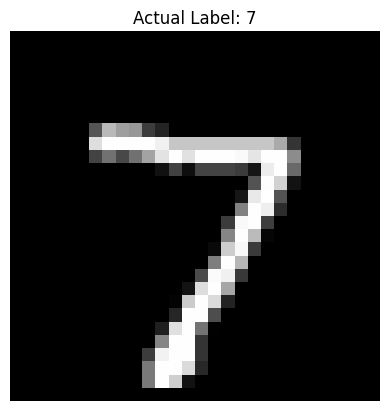

user picked image index :  0
Actual Label 7
Model Prediction  7


In [ ]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images , labels in test_loader:
        images = images.view(images.size(0) ,-1).to(device)
        labels = labels.to(device)

        outputs = model(images)

        # python method for numpy give the index number of maximum value 
        # dim = 1 get max value in row wise , 0 = column wise
        predictions = outputs.argmax(dim=1)

        correct+= (predictions == labels).sum().item()
        total+=labels.size(0)

accuracy = 100 * correct/total
print(f"Total accuracy: {accuracy:.2f}%")

torch.save(model.state_dict() , "mnist_model.pth")
print("Model saved as minst_model.pth")

index = 0
image , true_label = test_data[index]

plt.imshow(image.squeeze() , cmap="grey")
plt.title(f"Actual Label: {true_label}")
plt.axis("off")
plt.show()

image_flat = image.view(1,-1).to(device)


# no changes in gradient value (each learning variable has gradient value )
# when we run loss.backward() it generates grad value which tells increase the value or decrese the value of varible
# loss.backward will not work in no_grad area
# it saves memory by no storing computation with learning variable in database
# no changes in gradient , works with existing gradient weight and bias


with torch.no_grad():
    output = model(image_flat)
    predicted_label = output.argmax(dim=1).item()

print("user picked image index : ", index)
print("Actual Label" , true_label)
print("Model Prediction " , predicted_label)



